# 2장 1강: 시계열 데이터의 이해와 정상성 진단

## 실습 목표

이번 실습에서는 **Bike Sharing Demand** 데이터를 이용해 시간에 따른 자전거 대여량 변화를 확인합니다.

- 시계열 데이터에서 **시간 순서가 중요한 이유**를 확인합니다.
- 선 그래프와 시계열 분해를 이용해 **Trend / Seasonality / Residual**을 확인합니다.
- 이동평균을 이용해 데이터의 평균적인 수준 변화를 살펴봅니다.
- **ADF Test**를 이용해 정상성을 진단합니다.
- 정상성을 만족하지 않는 경우 **1차 차분**을 적용하고 ADF Test를 다시 수행합니다.

> 이 실습에서는 교안에서 다룬 내용만 사용합니다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- statsmodels
- 데이터: `Bike_Sharing_Demand.csv`

### 주요 컬럼

| 컬럼 | 의미 |
|---|---|
| `datetime` | 자전거 대여 기록 시각 |
| `casual` | 비등록 사용자의 대여 수 |
| `registered` | 등록 사용자의 대여 수 |
| `count` | 전체 자전거 대여 수 |

`count`는 `casual + registered`로 구성된 전체 대여량입니다.

## 실습 준비

먼저 데이터를 불러온 뒤 다음 내용을 확인합니다.

1. 데이터 크기와 상위 행
2. 주요 컬럼의 자료형
3. 결측치
4. `datetime`을 날짜/시간 자료형으로 변환
5. 시간 순서대로 정렬
6. 일별·월별 대여량 데이터 준비

> 일별·월별 집계 코드는 이후 시계열 실습을 위한 **준비 코드**로 제공됩니다.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

bike = pd.read_csv("Bike_Sharing_Demand.csv")

print("데이터 크기:", bike.shape)
display(bike.head())

print("\n[자료형]")
display(bike[["datetime", "casual", "registered", "count"]].dtypes.to_frame("dtype"))

print("\n[결측치]")
display(bike[["datetime", "casual", "registered", "count"]].isna().sum().to_frame("missing"))

데이터 크기: (10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1



[자료형]


,dtype
datetime,str
casual,int64
registered,int64
count,int64



[결측치]


,missing
datetime,0
casual,0
registered,0
count,0


In [3]:
# datetime 변환 및 시간 순서 정렬
bike["datetime"] = pd.to_datetime(bike["datetime"])
bike = bike.sort_values("datetime").reset_index(drop=True)

print("최초 시각:", bike["datetime"].min())
print("마지막 시각:", bike["datetime"].max())
display(bike.head())

최초 시각: 2011-01-01 00:00:00
마지막 시각: 2012-12-19 23:00:00


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [4]:
# 일별 시계열 준비
bike["date"] = bike["datetime"].dt.date

daily = (bike.groupby("date", as_index=False)[["count", "casual", "registered"]].sum())

daily["date"] = pd.to_datetime(daily["date"])

# 월별 시계열 준비
bike["month"] = bike["datetime"].dt.to_period("M").astype(str)

monthly = (bike.groupby("month", as_index=False)["count"].sum())

monthly["month"] = pd.to_datetime(monthly["month"])

print("[일별 데이터]")
display(daily.head())

print("\n[월별 데이터]")
display(monthly.head())

[일별 데이터]


,date,count,casual,registered
0,2011-01-01,985,331,654
1,2011-01-02,801,131,670
2,2011-01-03,1349,120,1229
3,2011-01-04,1562,108,1454
4,2011-01-05,1600,82,1518



[월별 데이터]


,month,count
0,2011-01-01,23552
1,2011-02-01,32844
2,2011-03-01,38735
3,2011-04-01,50517
4,2011-05-01,79713


---

# 필수 1. 시간 흐름과 시계열 패턴 확인

## 배경

시계열 데이터는 값 자체뿐만 아니라 **언제 관측되었는지와 어떤 순서로 나타났는지**가 중요합니다.

Bike Sharing Demand 데이터의 전체 대여량 `count`를 시간 순서대로 확인하고, 월별 대여량을 **Trend / Seasonality / Residual**로 나누어 살펴봅니다.

## 문제 1. 일별 대여량을 시간 순서대로 확인하세요.

### 요구사항

1. `daily["date"]`를 x축, `daily["count"]`를 y축으로 선 그래프를 그립니다.
2. 그래프 제목을 `Daily Bike Rentals`로 설정합니다.
3. 시간의 흐름에 따라 대여량의 전반적인 수준이 어떻게 변화하는지 설명합니다.

### 확인 포인트

- 시계열 그래프에서는 시간 순서를 유지했는가?
- 단순히 개별 값만 보는 것이 아니라 전체적인 흐름을 확인했는가?

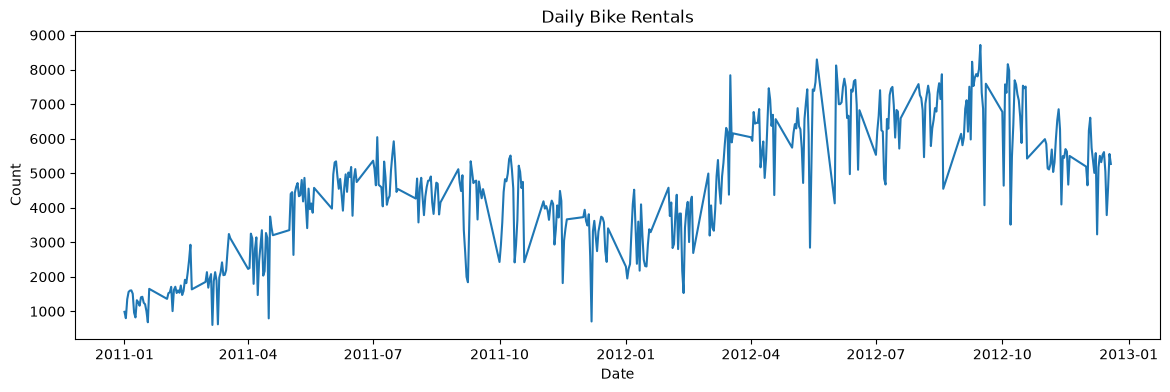

date
2011-01-01     985.0
2011-01-02     801.0
2011-01-03    1349.0
2011-01-04    1562.0
2011-01-05    1600.0
               ...  
2012-12-15    5047.0
2012-12-16    3786.0
2012-12-17    4585.0
2012-12-18    5557.0
2012-12-19    5267.0
Name: count, Length: 456, dtype: float64


In [5]:
# TODO
# daily["date"]와 daily["count"]를 이용해 선 그래프를 그려보세요.
plt.figure(figsize=(14,4))
plt.plot(daily['date'], daily['count'])
plt.title('Daily Bike Rentals')
plt.xlabel('Date')
plt.ylabel('Count')
plt.show()

print(daily.groupby(daily['date'])['count'].mean())

### Q1. 왜 `daily` 데이터를 무작위로 섞지 않고 날짜 순서대로 확인해야 할까요?

**답변:**  시계열 데이터는 값이 언제 관측되었는지와 그 순서 자체가 의미를 가지기 때문이다. 무작위로 섞으면 시간이 지나면서 대여량이 어떻게 변화하는지 등의 시간에 따른 패천이 사라진다. 실제 그래프를 보면 2011년보다 2012년의 대여량 수준이 전반적으론 높다. 또 각 해마다 봄 ~ 가을에 올라갔다가 겨울에 다시 내려가는 흐름이 보이는데 이런 패턴은 날짜 순서를 유지해야만 확인 가능하다.

## 문제 2. 월별 대여량을 시계열 분해하세요.

### 요구사항

1. `monthly`의 `month`를 인덱스로 설정합니다.
2. `seasonal_decompose()`를 사용합니다.
3. `model="additive"`를 사용합니다.
4. 월별 데이터의 1년 반복 주기를 확인하기 위해 `period=12`를 사용합니다.
5. 결과에서 `Observed`, `Trend`, `Seasonal`, `Residual`을 확인합니다.

### 확인 포인트

- `period=12`의 의미를 이해했는가?
- Trend / Seasonality / Residual을 구분할 수 있는가?

계절별 앞 12개: 
month
2011-01-01   -33250.0
2011-02-01   -26473.0
2011-03-01    -2194.0
2011-04-01    15645.0
2011-05-01    15733.0
2011-06-01    23237.0
2011-07-01    25648.0
2011-08-01    13337.0
2011-09-01     5418.0
2011-10-01      736.0
2011-11-01   -12359.0
2011-12-01   -25478.0
Name: seasonal, dtype: float64


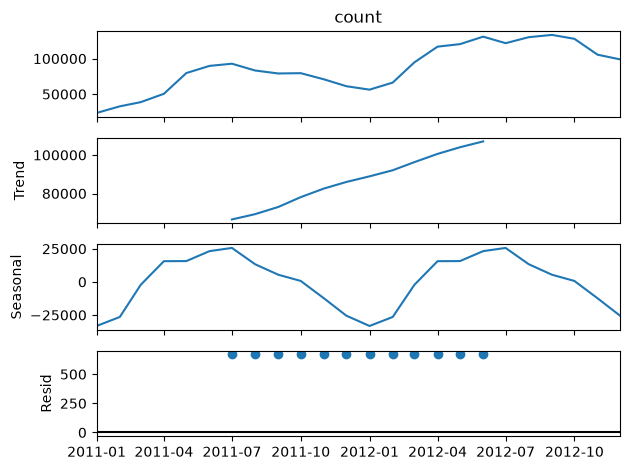

In [12]:
# TODO
# seasonal_decompose()를 이용해 월별 count를 분해해보세요.
monthly_si = monthly.set_index('month')

result = seasonal_decompose(monthly_si['count'], model='additive', period=12)
result.plot()

print(f'계절별 앞 12개: \n{result.seasonal.head(12).round(0)}')

### Q2. 다음 설명을 각각 Trend / Seasonality / Residual과 연결하세요.

- 시간이 지나면서 나타나는 장기적인 증가 또는 감소
- 일정한 시간 간격을 두고 반복되는 변화
- 추세와 계절성을 제외하고 남은 변동

**답변:**  
- 시간이 지나면서 나타나는 장기적 증가 혹은 감소 -> 트렌드 / 분해 결과에서 2011년 중반부터 2012년 중반까지 계속 올로가는 경향성 확인 가능
- 일정한 시간 간격을 두고 반복되는 변화 -> 계절성 / period=12 로 1년 주기를 잡았고  여름에  +로 겨울에 -로 반복되는 경향성 확인 가능
- 추세와 계절성을 제외하고 남은 변동 -> residual(잔차)


---

# 필수 2. 정상성 진단과 1차 차분

## 배경

정상성은 시간이 지나도 시계열의 **평균적인 수준과 변동의 특성이 크게 달라지지 않는 성질**입니다.

이번 문제에서는 일별 전체 대여량 `count`의 이동평균을 확인하고, ADF Test를 이용해 정상성을 판단합니다. 정상성을 만족한다고 보기 어렵다면 1차 차분을 수행한 뒤 다시 ADF Test를 진행합니다.

## 문제 1. 이동평균으로 평균 수준의 변화를 확인하세요.

### 요구사항

1. `daily["count"]`의 최근 7개 값 이동평균을 계산하여 `rolling_mean` 컬럼에 저장합니다.
2. 원본 `count`와 `rolling_mean`을 같은 그래프에 나타냅니다.
3. 이동평균이 시간에 따라 변하는지 확인합니다.

### 확인 포인트

- `rolling(window=7).mean()`을 사용했는가?
- 이동평균이 개별 값의 작은 변동을 줄여 전체 수준을 보기 위한 방법임을 이해했는가?

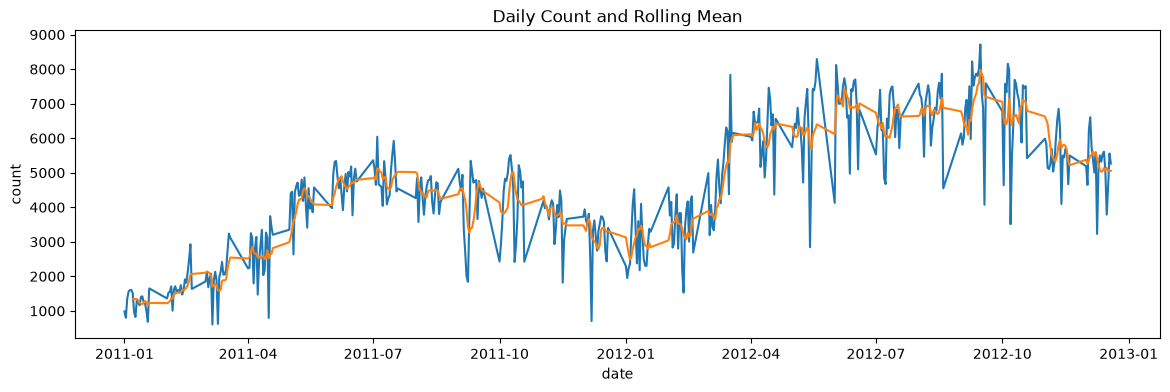

        date  count  rolling_mean
0 2011-01-01    985           NaN
1 2011-01-02    801           NaN
2 2011-01-03   1349           NaN
3 2011-01-04   1562           NaN
4 2011-01-05   1600           NaN
5 2011-01-06   1606           NaN
6 2011-01-07   1510   1344.714286
7 2011-01-08    959   1341.000000
8 2011-01-09    822   1344.000000
9 2011-01-10   1321   1340.000000


In [16]:
# TODO
# 7개 값 이동평균을 계산하고 원본 count와 함께 시각화하세요.
daily['rolling_mean'] = daily['count'].rolling(window=7).mean()

plt.figure(figsize=(14,4))
plt.plot(daily['date'], daily['count'], label='count')
plt.plot(daily['date'], daily['rolling_mean'], label='rolling_mean')
plt.title('Daily Count and Rolling Mean')
plt.xlabel('date')
plt.ylabel('count')
plt.show()

print(daily[['date', 'count', 'rolling_mean']].head(10))

## 문제 2. 원본 일별 대여량에 ADF Test를 수행하세요.

### 요구사항

1. `adfuller()`를 이용해 `daily["count"]`를 검정합니다.
2. ADF Statistic과 p-value를 출력합니다.
3. 유의수준 0.05를 기준으로 정상성을 판단합니다.

### 판단 기준

- `p-value < 0.05` → 귀무가설 기각 → 정상성을 만족한다고 판단
- `p-value ≥ 0.05` → 귀무가설을 기각하지 못함 → 정상성을 만족한다고 보기 어려움

In [18]:
# TODO
# 원본 daily["count"]에 ADF Test를 수행하세요.
adf_result = adfuller(daily['count'])
print(f'ADF 통계량: {adf_result}')
print(f'p-value: {adf_result[1]}')

if adf_result[1] < 0.05:
    print(f'p-value < 0.05 -> 귀무가설 기각, 단위근 없음, 정상성 만족한다고 판단')
else: 
    print(f'p-value > 0.05 -> 대립가설 기각, 단위근 존재, 정상성 만족하지 못한다고 판단')

ADF 통계량: (-2.002469176220278, 0.2854915020281234, 9, 446, {'1%': np.float64(-3.4450973903602367), '5%': np.float64(-2.868042229965336), '10%': np.float64(-2.570233448893)}, np.float64(7147.388784509935))
p-value: 0.2854915020281234
p-value > 0.05 -> 대립가설 기각, 단위근 존재, 정상성 만족하지 못한다고 판단


C:\Users\mong0\AppData\Local\Temp\ipykernel_38252\1019719128.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(daily['count'])


### Q3. 원본 데이터의 p-value를 기준으로 정상성을 어떻게 판단할 수 있나요?

**답변:**  원본 daily['count']의 adf통계량은 -2.00, p-val은 0.285로 유의수준보다 크다. 따라서 귀무가설(단위근이 있다 = 비정상성)을 기각하지 못하므로 정상성을 만족한다고 보기 어려움. 이동평균 그래프에서도 평균 수준이 시간에 따라 계속해서 변하고 있어, 검정 결과와 같은 방향이다.

## 문제 3. 1차 차분 후 정상성을 다시 확인하세요.

### 요구사항

1. `.diff()`를 이용해 `daily["count"]`를 1차 차분합니다.
2. 첫 번째 `NaN`은 `dropna()`로 제거합니다.
3. 차분된 값을 선 그래프로 나타냅니다.
4. 차분 데이터에 ADF Test를 다시 수행합니다.
5. 차분 전과 차분 후 p-value를 비교하여 정상성 변화를 설명합니다.

### 확인 포인트

- 차분값이 `현재 값 - 이전 값`이라는 것을 이해했는가?
- 차분 후 데이터의 의미가 **일별 대여량 → 이적 관측일 대비 대여량 변화**로 달라짐을 이해했는가?
- 차분 후 ADF Test를 다시 수행했는가?

In [20]:
import matplotlib.pyplot as plt
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호(-)가 깨지는 것 방지

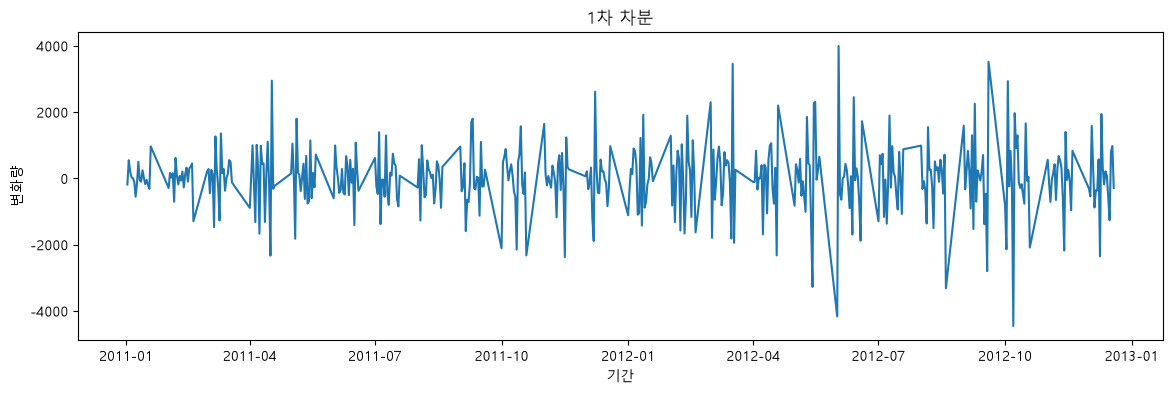

차분 후 adf 통계량: -11.751565383174505
차분 후 p-val: 1.2057220051150929e-21
차분 전 p-val: 0.2854915020281234
차분 후 p-val: 1.2057220051150929e-21


C:\Users\mong0\AppData\Local\Temp\ipykernel_38252\2859533785.py:12: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_diff = adfuller(count_diff)


In [22]:
# TODO
# 1차 차분 → 시각화 → ADF Test 재실행 순서로 진행하세요.
count_diff = daily['count'].diff().dropna() #첫번째 값은 앞에 값을 모름

plt.figure(figsize=(14,4))
plt.plot(daily['date'].iloc[1:], count_diff) #첫번째 값 모르니 두번째값부터 시작
plt.title('1차 차분')
plt.xlabel('기간')
plt.ylabel('변화량')
plt.show()

adf_diff = adfuller(count_diff)
print(f'차분 후 adf 통계량: {adf_diff[0]}')
print(f'차분 후 p-val: {adf_diff[1]}')

print(f'차분 전 p-val: {adf_result[1]}')
print(f'차분 후 p-val: {adf_diff[1]}')

### Q4. 차분 전과 차분 후 데이터의 의미는 어떻게 달라지나요?

**답변:**  차분 전 데이터는 각 날짜의 일별 대여량을 의미. 차분 후 데이터는 현재 값 - 이전값, 죽, 이전 관측일 대비 대여량이 얼마나 변화했는지를 의미. 차분 후 그래프는 0을 중심으로 위아래로 움직여서 평균 수준이 크게 변하지 않음. adf p-val도 약 0.285에서 1.2e-21로 유의수준보다 훨씬 작아졌으므로 귀무가설(단위근이 존재한다)를 기각하고 정상성을 만족한다고 판단 가능.


---

# 과제 1. 등록 사용자 대여량의 정상성 진단

## 배경

필수 2에서는 전체 대여량 `count`를 이용해 정상성 진단과 차분을 수행했습니다.

이번에는 같은 과정을 **등록 사용자 대여량 `registered`**에 직접 적용합니다.

> 과제는 필수 실습에서 연습한 방법을 동일하게 적용하는 수준입니다.

## 요구사항

1. `daily["registered"]`를 날짜 순서대로 선 그래프로 나타냅니다.
2. 최근 7개 값의 이동평균을 계산하여 원본 데이터와 함께 나타냅니다.
3. 원본 `registered`에 ADF Test를 수행합니다.
4. p-value를 기준으로 정상성을 판단합니다.
5. 정상성을 만족한다고 보기 어렵다면 1차 차분합니다.
6. 1차 차분을 수행한 경우, 차분 데이터에 ADF Test를 다시 수행합니다.
7. 원본과 차분 데이터의 p-value를 근거로 정상성 판단을 설명합니다. 차분하지 않았다면 그 이유를 설명합니다.
8. 진단 결과를 근거로 원본 데이터를 사용할지, 1차 차분한 데이터를 사용할지, 추가 진단이 필요한지 선택하고 이유를 설명합니다.

### 확인 포인트

- 원본 데이터의 시간 흐름을 확인했는가?
- 이동평균으로 평균 수준의 변화를 확인했는가?
- ADF Test의 p-value를 0.05와 비교했는가?
- 필요한 경우 1차 차분 후 ADF Test를 다시 수행했는가?
- 결과를 코드 출력값을 근거로 설명했는가?
- ADF 검정 결과와 그래프를 근거로 이후 모델링 방향을 선택했는가?


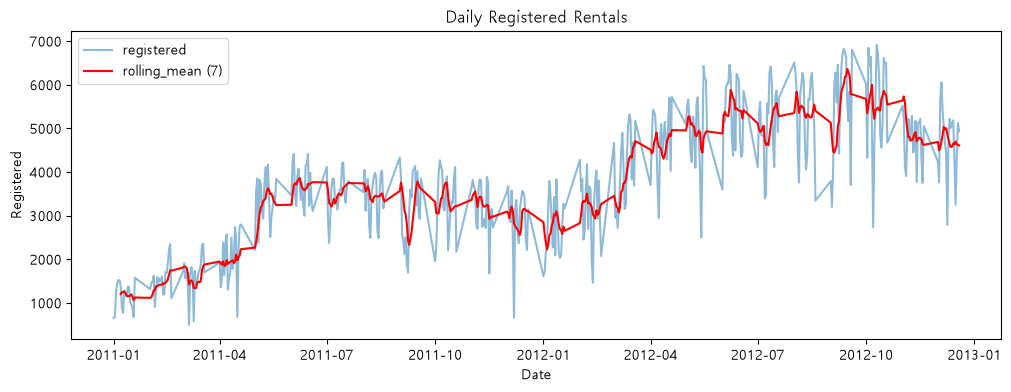

원본 adf 통계량: -1.906961635000746
원본 adf p-val: 0.3287932585821237
단위근이 존재한다 -> 정상성 만족하지 못한다.


C:\Users\mong0\AppData\Local\Temp\ipykernel_38252\185205561.py:16: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  reg_adf = adfuller(daily['registered'])
C:\Users\mong0\AppData\Local\Temp\ipykernel_38252\185205561.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


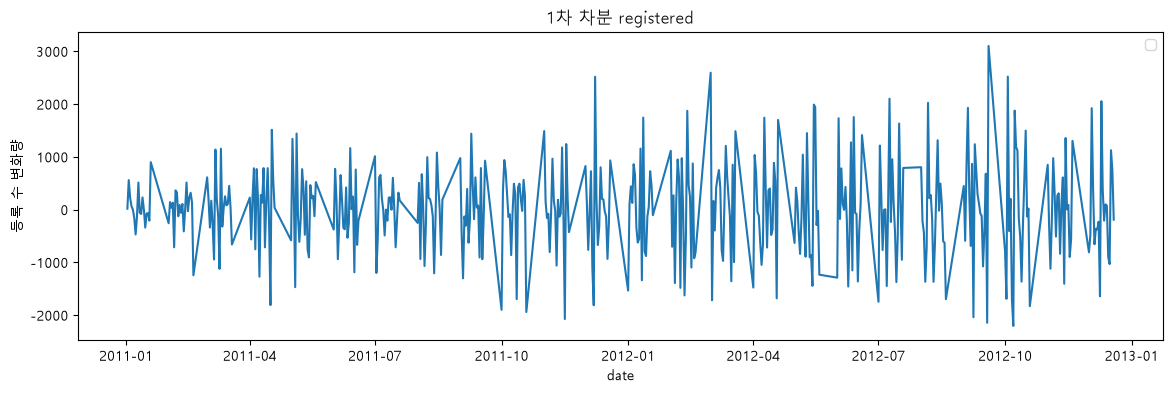

차분 후 registered adf 통계량: -6.353678332846805
차분 후 registered adf p-val: 2.5738584410443542e-08


C:\Users\mong0\AppData\Local\Temp\ipykernel_38252\185205561.py:35: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  reg_adf_diff = adfuller(reg_diff)


In [28]:
# TODO
# 시각화 → 최근 7개 값 이동평균 → 원본 ADF Test
# → 필요 시 1차 차분 및 ADF Test 재실행 → 결과 비교
# Q5·Q6에는 출력값과 그래프를 근거로 해석과 모델링 방향을 작성하세요.
daily["reg_rolling_mean"] = daily["registered"].rolling(window=7).mean()

plt.figure(figsize=(12, 4))
plt.plot(daily["date"], daily["registered"], label="registered", alpha=0.5)
plt.plot(daily["date"], daily["reg_rolling_mean"], label="rolling_mean (7)", color="red")
plt.title("Daily Registered Rentals")
plt.xlabel("Date")
plt.ylabel("Registered")
plt.legend()
plt.show()

reg_adf = adfuller(daily['registered'])
print(f'원본 adf 통계량: {reg_adf[0]}')
print(f'원본 adf p-val: {reg_adf[1]}')

if reg_adf[1] < 0.05:
    print(f'단위근이 없다 -> 정상성 만족한다')
else:
    print(f'단위근이 존재한다 -> 정상성 만족하지 못한다.')


reg_diff = daily['registered'].diff().dropna()
plt.figure(figsize=(14,4))
plt.plot(daily['date'].iloc[1:], reg_diff)
plt.title('1차 차분 registered')
plt.xlabel('date')
plt.ylabel('등록 수 변화량')
plt.legend()
plt.show()

reg_adf_diff = adfuller(reg_diff)
print(f'차분 후 registered adf 통계량: {reg_adf_diff[0]}')
print(f'차분 후 registered adf p-val: {reg_adf_diff[1]}')

### Q5. 원본 등록 사용자 대여량의 ADF 검정 결과를 어떻게 해석할 수 있나요? 차분했다면 차분 전후 결과를 비교하고, 차분하지 않았다면 그 이유를 설명하세요.

**답변:** registered의 ADF Statistic은 약 -1.91, p-value는 약 0.329로 0.05보다 큽니다. 따라서 귀무가설을 기각하지 못하고 정상성을 만족한다고 보기 어려워서 1차 차분을 진행했습니다. 1차 차분 후에는 ADF Statistic이 약 -6.35, p-value가 약 2.6e-08로 0.05보다 훨씬 작아졌습니다. 따라서 귀무가설을 기각하고 정상성을 만족한다고 판단할 수 있습니다. 그래프에서도 원본은 이동평균이 2011년에서 2012년으로 갈수록 올라가지만, 차분 데이터는 0 근처를 중심으로 움직입니다.

### Q6. 이후 시계열 모델링에서는 원본 데이터 사용, 1차 차분 데이터 사용, 추가 진단 중 어떤 방향을 선택하겠나요? ADF 검정 결과와 그래프를 근거로 설명하세요.

**답변:** 1차 차분 데이터를 사용하는 방향을 선택하겠습니다. 원본은 p-value가 약 0.329로 정상성을 만족한다고 보기 어렵고, 이동평균 그래프에서도 평균 수준이 시간에 따라 변합니다. 반면 1차 차분 후에는 p-value가 약 2.6e-08로 정상성을 만족하고, 그래프도 0을 중심으로 움직입니다. 다만 두 가지는 모델링할 때 한계로 함께 고려해야 할 것 같습니다. 하나는 차분 그래프의 변동 폭이 2011년에는 대략 ±1,500 안쪽인데 2012년에는 ±2,000~3,000까지 커진다는 점입니다. 다른 하나는 매월 20일 이후 데이터가 없어서 날짜가 건너뛴다는 점입니다.


---

# 실습 마무리

아래 질문에 짧게 답해보세요.

1. 시간 순서가 중요한 이유: 값이 관측된 순서에 추세와 계절성 같은 패턴이 담겨 있어서, 순서를 섞으면 그 흐름을 확인할 수 없기 때문입니다.
2. Trend와 Seasonality의 차이: Trend는 장기적으로 증가하거나 감소하는 방향이고, Seasonality는 일정한 주기(예: 1년)마다 반복되는 변화입니다.
3. p-value ≥ 0.05의 해석: 귀무가설을 기각하지 못하므로 정상성을 만족한다고 보기 어렵다고 해석합니다.
4. 1차 차분이 계산하는 값: 현재 값에서 이전 값을 뺀 값, 즉 변화량을 계산합니다.
5. 차분 후 ADF Test를 다시 하는 이유: 차분을 했다고 무조건 정상성이 생기는 것은 아니어서, 차분한 데이터가 실제로 정상성을 만족하는지 다시 확인해야 하기 때문입니다.
